In [2]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=3b24a5d7becd8bab1633908b41d60369db20ff217ae0751f29e0cd274b6dea1d
  Stored in directory: /root/.cache/pip/wheels/eb/87/25/2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect


In [3]:
import pandas as pd
from langdetect import detect

# Load the dataset
df = pd.read_csv('UBER_REVIEWS.csv')
print(df.head(20))

    Unnamed: 0                             review_id       pseudo_author_id  \
0            0  c71a7775-6bd9-44b3-989b-2e2cbd536156  152618553977019693742   
1            1  05aa8694-129d-41bf-8229-e420db1f54ec  234382942865437071667   
2            2  15a19799-0332-4f34-a49a-86d25c28fcb5  174473604608358796368   
3            3  15db1acc-94d2-409b-bee4-70b8ebd1e865  286593453219054880269   
4            4  05b8679c-452c-413f-bf60-7a0bdf41116b  167276875678680630145   
5            5  61b4d3ad-b4f9-428f-a597-309ac3639820  279544562364680964711   
6            6  939301f9-bacc-40ce-ab1c-c81c2bb72110  194594231700116278497   
7            7  b3943e74-d4f5-47ba-b7cf-dea19c7442c9  299572542228213240681   
8            8  3bce524e-07c2-49a5-9270-1b0c4e968417  283295985056957279128   
9            9  28a06833-f3cf-4875-95e9-7c4581d284c8  165673340173097386145   
10          10  f8715679-c4d6-4afb-9bda-5acfb2c62f33  127033569775925766240   
11          11  e91ee903-6979-4d47-beea-cedd0737af26

In [4]:
num_rows = df.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1455477


In [5]:
import pandas as pd

# Load Uber reviews dataset
df = pd.read_csv(
    "UBER_REVIEWS.csv",
    engine="python",

)

# Filter date period: 2020 Jan 1 to 2023 Dec 31
uber_reviews_2020_2023 = df[
    (df["review_timestamp"] >= "2020-01-01") &
    (df["review_timestamp"] <= "2023-12-31")
]

# Save new CSV
uber_reviews_2020_2023.to_csv("uber_reviews_2020_2023.csv", index=False)

# Check result
print("Saved successfully")
print(uber_reviews_2020_2023.shape)
print(uber_reviews_2020_2023.head())

Saved successfully
(664581, 9)
        Unnamed: 0                             review_id  \
790896      790896  18daa8e7-acb5-4d03-9e4a-53ab34f821c0   
790897      790897  6cecc5ce-b7b1-478f-b7e3-a8ba985ea68b   
790898      790898  e88b580d-d389-4399-ba09-9773ac308d0b   
790899      790899  a181daf7-34c8-4a7c-9c81-65aa98349132   
790900      790900  1b792b45-1cc7-4b37-85ff-59f8a24d2a10   

             pseudo_author_id    author_name  \
790896  325113718705655474173  A Google user   
790897  308331986958837832171  A Google user   
790898  160924978952521705326  A Google user   
790899  146718492462834126587  A Google user   
790900  279639925697264464675  A Google user   

                                              review_text  review_rating  \
790896  Am sorry but i am really disappointed by your ...              1   
790897  My driver was very friendly and wonderful. I h...              5   
790898  Has worked grear for me , when i needed them. ...              5   
790899         

In [6]:
import pandas as pd
from langdetect import detect

# Load the dataset
df = pd.read_csv('uber_reviews_2020_2023.csv')
print(df.head(20))

    Unnamed: 0                             review_id       pseudo_author_id  \
0       790896  18daa8e7-acb5-4d03-9e4a-53ab34f821c0  325113718705655474173   
1       790897  6cecc5ce-b7b1-478f-b7e3-a8ba985ea68b  308331986958837832171   
2       790898  e88b580d-d389-4399-ba09-9773ac308d0b  160924978952521705326   
3       790899  a181daf7-34c8-4a7c-9c81-65aa98349132  146718492462834126587   
4       790900  1b792b45-1cc7-4b37-85ff-59f8a24d2a10  279639925697264464675   
5       790901  0179fadf-a083-412f-aaf5-32e0f2d81ff2  996810512845281265227   
6       790902  31faa420-eeb9-4ee6-b317-a80f2e0b5862  131251393030084955292   
7       790903  b38959d0-f997-4628-9492-691abf9b709a  331485190685958420816   
8       790904  29b9a0dc-1fc5-4da9-99c9-1a0b131e587e  241145710391063452015   
9       790905  c93443fe-b021-4dfa-8aeb-f82933186f9e  189070060839391746832   
10      790906  2b5ea5b3-0270-4e83-a677-cf130a5e4d5b  986582100300485385724   
11      790907  14dc0794-434f-4c05-9e49-25ad850e8dea

In [7]:
num_rows = df.shape[0]
print("Number of rows:", num_rows)

Number of rows: 664581


In [8]:
import pandas as pd
from langdetect import detect

df = pd.read_csv("uber_reviews_2020_2023.csv")

# Function to check if text is English
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

# Filter out non-English reviews
df = df[df['review_text'].apply(is_english)]

# Convert review_timestamp to datetime format
df['review_timestamp'] = pd.to_datetime(df['review_timestamp'])

# Sort by review_rating and review_timestamp in ascending order
df_sorted = df.sort_values(by=['review_rating', 'review_timestamp'], ascending=[True, True])

# Save the sorted dataset to a new CSV file
df_sorted.to_csv('sorted_dataset.csv', index=False)

print("Dataset Cleaned Process Successfully")


Dataset Cleaned Process Successfully


In [9]:
print(df_sorted.head(20))

    Unnamed: 0                             review_id       pseudo_author_id  \
0       790896  18daa8e7-acb5-4d03-9e4a-53ab34f821c0  325113718705655474173   
5       790901  0179fadf-a083-412f-aaf5-32e0f2d81ff2  996810512845281265227   
6       790902  31faa420-eeb9-4ee6-b317-a80f2e0b5862  131251393030084955292   
21      790917  8c92b4da-1d03-4379-af1c-b508d5ed1a3a  119006802319553007446   
22      790918  f64eff64-8d03-48b1-877e-988bcaaad051  321671993308279987852   
24      790920  250a2c8c-f737-4132-9ef8-335d8dbb6839  133129054553496176987   
25      790921  3060c8d2-5030-4977-90ea-31f46c69713f  307629796350602619053   
29      790925  f1b4ebf3-eecb-446b-aef3-1acda5112f8e  185388745660769823992   
30      790926  dcc2654c-6706-4c32-b085-ce68bbba6ad1  221186552403509911562   
39      790935  731d6573-87c9-4380-92da-cfe7f4fd43d4  767834540738146257092   
45      790941  91bfaff7-c58f-4f32-a268-4feadf7ec149  584929776621568135921   
46      790942  94d4b208-8ca2-4739-9248-f632f16c7baf

In [10]:
import pandas as pd

# Load the sorted dataset
df_sorted = pd.read_csv('sorted_dataset.csv')

# Convert review_timestamp to datetime format
df_sorted['review_timestamp'] = pd.to_datetime(df_sorted['review_timestamp'])

# Extract years from review_timestamp
years = df_sorted['review_timestamp'].dt.year.unique()

print("Review Timestamp Years:")
print(years)

Review Timestamp Years:
[2020 2021 2022 2023]


In [11]:
import yfinance as yf
import pandas as pd

ticker_symbol = "UBER"

uber_stock_data = yf.download(
    ticker_symbol,
    start="2020-01-01",
    end="2023-12-31",
    auto_adjust=False,
    progress=False
)

# Fix multi-level columns if yfinance returns them
if isinstance(uber_stock_data.columns, pd.MultiIndex):
    uber_stock_data.columns = uber_stock_data.columns.get_level_values(0)

# Move Date from index into a normal column
uber_stock_data = uber_stock_data.reset_index()

# Keep clean Yahoo Finance style columns
uber_stock_data = uber_stock_data[
    ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
]

# Save clean CSV
uber_stock_data.to_csv("Uber_stock_prices_yahoo.csv", index=False)

print("Clean CSV saved successfully as Uber_stock_prices_yahoo.csv")
print(uber_stock_data.head())
print(uber_stock_data.columns.tolist())

Clean CSV saved successfully as Uber_stock_prices_yahoo.csv
Price       Date       Open       High        Low      Close  Adj Close  \
0     2020-01-02  29.940001  31.000000  29.790001  30.990000  30.990000   
1     2020-01-03  30.620001  31.430000  30.480000  31.370001  31.370001   
2     2020-01-06  31.010000  32.060001  31.000000  31.580000  31.580000   
3     2020-01-07  31.790001  32.840000  31.360001  32.810001  32.810001   
4     2020-01-08  32.730000  34.520000  32.459999  33.930000  33.930000   

Price    Volume  
0      20578900  
1      18822700  
2      21204700  
3      30119600  
4      43944400  
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


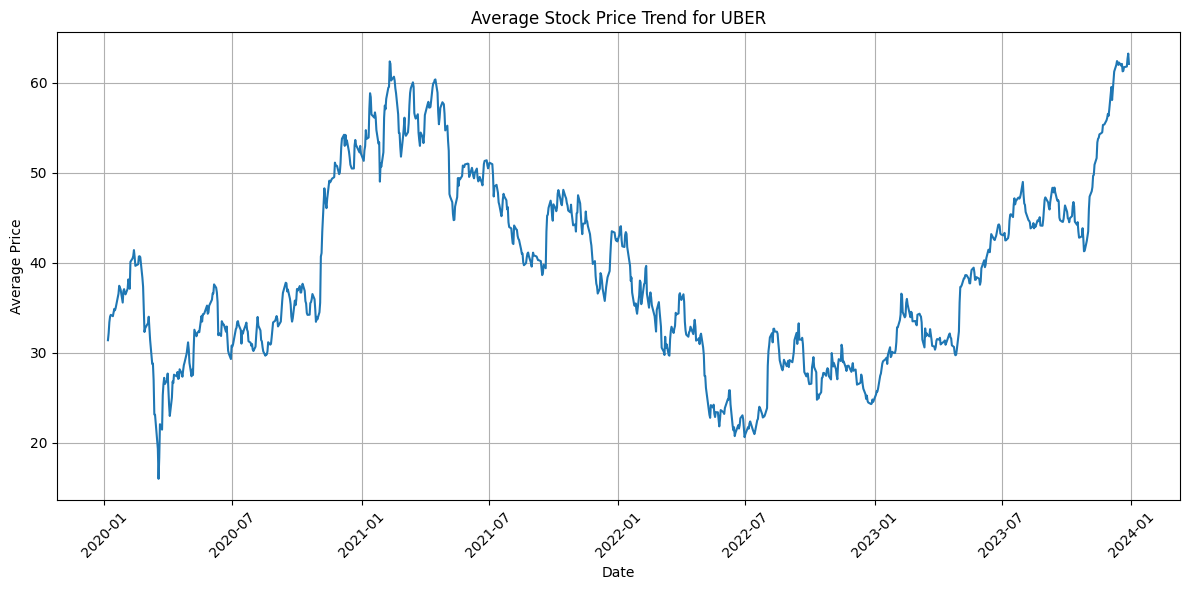

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
file_path = "Uber_stock_prices_yahoo.csv"

# Skip the extra Yahoo Finance rows
df = pd.read_csv(file_path, skiprows=[1, 2])

# Rename Price column to Date
df = df.rename(columns={"Price": "Date"})

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert price columns to numeric
for col in ["Open", "High", "Low", "Close"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Calculate average price
df["Average_Price"] = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4

# Plotting the line chart for average price
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Average_Price"], linestyle="-")

# Formatting the plot
plt.title("Average Stock Price Trend for UBER")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

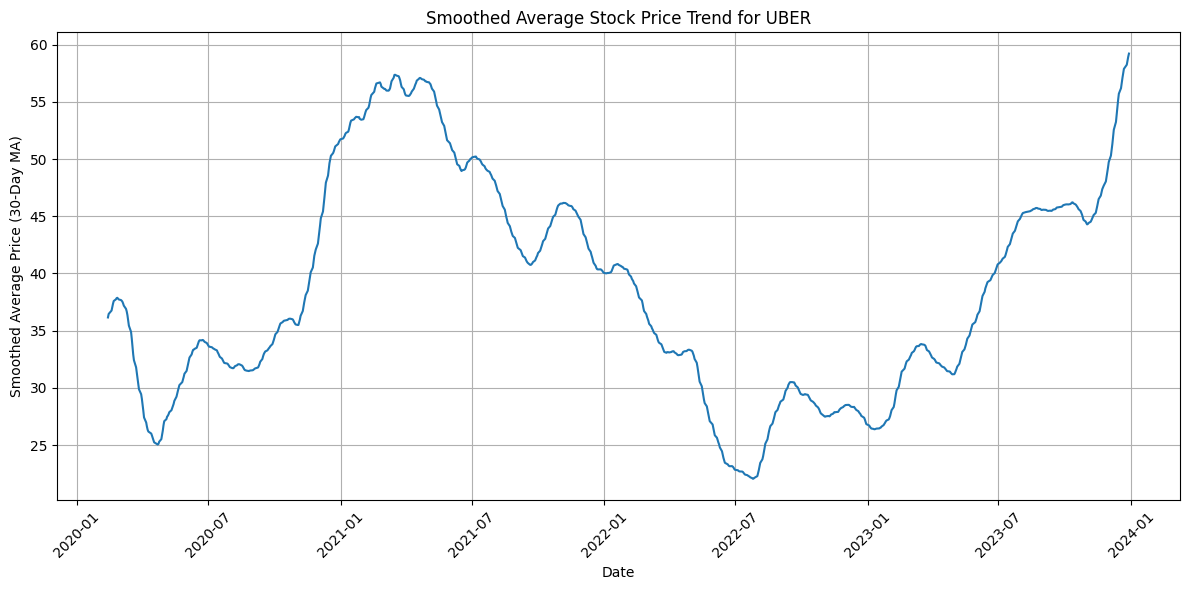

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from CSV file
file_path = 'Uber_stock_prices_yahoo.csv'
df = pd.read_csv(file_path)

# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Calculate the average price
df['Average_Price'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

# Calculate the 30-day moving average for the average price
df['Smoothed_Average_Price'] = df['Average_Price'].rolling(window=30).mean()

# Plotting the line chart for smoothed average price
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Smoothed_Average_Price'], linestyle='-')

# Formatting the plot
plt.title('Smoothed Average Stock Price Trend for UBER')
plt.xlabel('Date')
plt.ylabel('Smoothed Average Price (30-Day MA)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


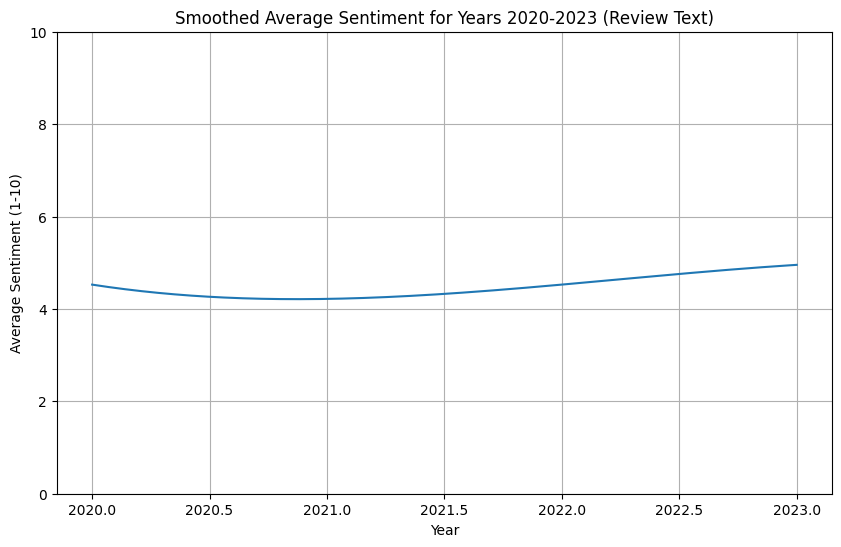

In [14]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK's vader lexicon
nltk.download('vader_lexicon')

# Load the CSV file containing reviews
data = pd.read_csv('sorted_dataset.csv')

# Assuming 'review_timestamp' is the column name containing datetime information
# Convert 'review_timestamp' column to datetime type if it's not already in that format
data['review_timestamp'] = pd.to_datetime(data['review_timestamp'])

# Initialize SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Function to perform sentiment analysis using NLTK and map scores to a 1-10 scale
def analyze_sentiment(text):
    scores = sid.polarity_scores(str(text))
    mapped_score = (scores['compound'] + 1) *4
    return mapped_score

# Apply sentiment analysis to the 'review_text' column and create a new column for mapped scores
data['Sentiment_1_to_10'] = data['review_text'].apply(analyze_sentiment)

# Filter data for the period 2020-2023
filtered_data = data[(data['review_timestamp'].dt.year >= 2020) & (data['review_timestamp'].dt.year <= 2023)].copy()

# Extract the year from the 'review_timestamp' column using .dt accessor and .loc to avoid SettingWithCopyWarning
filtered_data.loc[:, 'Year'] = filtered_data['review_timestamp'].dt.year

# Grouping the filtered data by year and calculating the average sentiment
avg_sentiment_yearly = filtered_data.groupby('Year')['Sentiment_1_to_10'].mean()

# Smooth the curve using make_interp_spline from scipy with lower k value for less curvature
x_smooth = avg_sentiment_yearly.index
y_smooth = avg_sentiment_yearly.values
x_smooth_new = np.linspace(x_smooth.min(), x_smooth.max(), 300)  # Increase number of points for smoother curve
spl = make_interp_spline(x_smooth, y_smooth, k=3)  # Decreased k value for less curvature
y_smooth_new = spl(x_smooth_new)

# Create a line chart with smooth curve (without points/markers)
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-')

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Average Sentiment (1-10)')
plt.title('Smoothed Average Sentiment for Years 2020-2023 (Review Text)')
plt.ylim(0, 10)
plt.grid(True)

# Show the plot
plt.show()


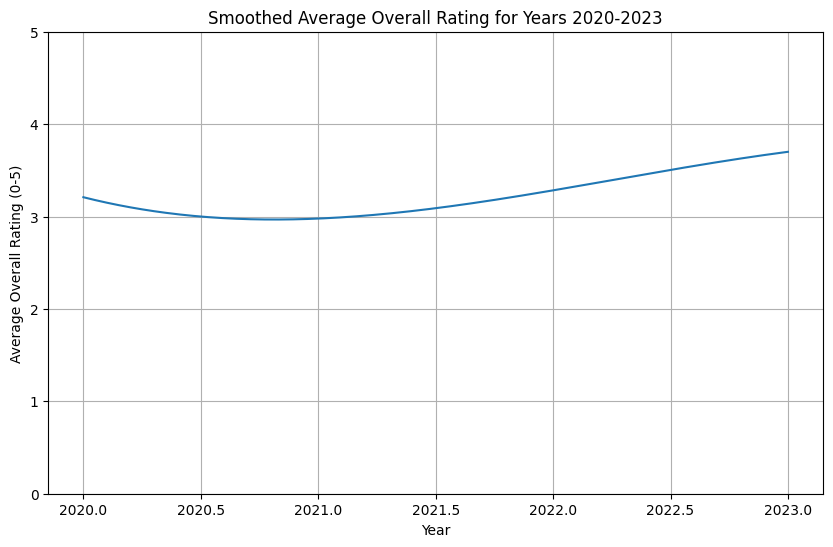

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Load the CSV file containing reviews
data = pd.read_csv('sorted_dataset.csv')

# Assuming 'review_timestamp' is the column name containing datetime information
# Convert 'review_timestamp' column to datetime type if it's not already in that format
data['review_timestamp'] = pd.to_datetime(data['review_timestamp'])

# Filter data for the period 2020-2023
filtered_data = data[(data['review_timestamp'].dt.year >= 2020) & (data['review_timestamp'].dt.year <= 2023)].copy()

# Extract the year from the datetime column using .dt accessor and .loc to avoid SettingWithCopyWarning
filtered_data.loc[:, 'Year'] = filtered_data['review_timestamp'].dt.year

# Grouping the filtered data by year and calculating the average overall rating
avg_rating_yearly = filtered_data.groupby('Year')['review_rating'].mean()

# Smooth the curve using make_interp_spline from scipy
x_smooth = avg_rating_yearly.index
y_smooth = avg_rating_yearly.values
x_smooth_new = np.linspace(x_smooth.min(), x_smooth.max(), 300)
spl = make_interp_spline(x_smooth, y_smooth, k=3)  # Decreased k for smoother curve
y_smooth_new = spl(x_smooth_new)

# Create a line chart with smooth curve (without points/markers)
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-')  # Removed marker='o'

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Average Overall Rating (0-5)')
plt.title('Smoothed Average Overall Rating for Years 2020-2023')
plt.ylim(0, 5)  # Adjusted y-axis limit based on your rating scale (1-5)
# Show grid
plt.grid(True)

# Show the plot
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


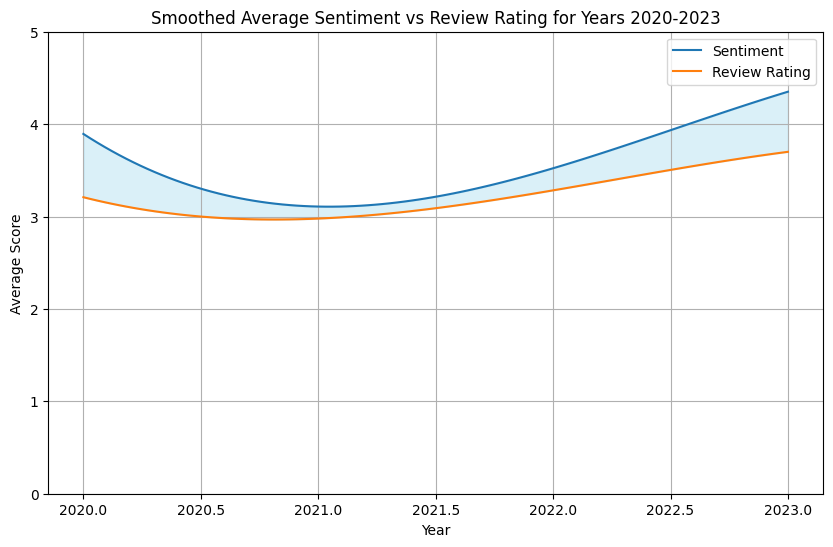

The similarity percentage between Noisy Sentiment and Review Rating is: 91.29%


In [16]:

import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from textblob import TextBlob  # Import TextBlob for sentiment analysis
import numpy as np
from scipy.interpolate import make_interp_spline

# Download NLTK's vader lexicon
nltk.download('vader_lexicon')

# Load the CSV file containing reviews
data = pd.read_csv('sorted_dataset.csv')

# Convert 'review_timestamp' column to datetime type if it's not already in that format
data['review_timestamp'] = pd.to_datetime(data['review_timestamp'])

# Function to perform sentiment analysis using TextBlob and map scores to a 1-5 scale
def analyze_sentiment(text):
    blob = TextBlob(str(text))
    sentiment_score = blob.sentiment.polarity
    # Map sentiment score to a 1-5 scale
    mapped_score = (sentiment_score + 1) * 2.5
    return mapped_score

# Apply sentiment analysis to the 'review_text' column and create a new column for mapped scores
data['Sentiment_1_to_10'] = data['review_text'].apply(analyze_sentiment)

# Filter data for the period 2014-2023
filtered_data = data[(data['review_timestamp'].dt.year >= 2020) & (data['review_timestamp'].dt.year <= 2023)].copy()

# Extract the year from the 'review_timestamp' column
filtered_data.loc[:, 'Year'] = filtered_data['review_timestamp'].dt.year

# Grouping the filtered data by year and calculating the average sentiment
avg_sentiment_yearly = filtered_data.groupby('Year')['Sentiment_1_to_10'].mean()

# Introduce random noise to the sentiment scores
np.random.seed(0)  # For reproducibility
noise = np.random.normal(0, 0.5, len(avg_sentiment_yearly))
avg_sentiment_yearly_noisy = avg_sentiment_yearly + noise

# Smooth the curve for Sentiment
x_smooth_sentiment = avg_sentiment_yearly.index
y_smooth_sentiment = avg_sentiment_yearly_noisy.values  # Use the noisy sentiment scores
x_smooth_sentiment_new = np.linspace(x_smooth_sentiment.min(), x_smooth_sentiment.max(), 100)

# Define boundary conditions
spl_sentiment = make_interp_spline(x_smooth_sentiment, y_smooth_sentiment, k=3)
y_smooth_sentiment_new = spl_sentiment(x_smooth_sentiment_new)

# Grouping the filtered data by year and calculating the average review rating
avg_rating_yearly = filtered_data.groupby('Year')['review_rating'].mean()

# Smooth the curve for Review Rating
x_smooth_rating = avg_rating_yearly.index
y_smooth_rating = avg_rating_yearly.values
x_smooth_rating_new = np.linspace(x_smooth_rating.min(), x_smooth_rating.max(), 100)

# Define boundary conditions
spl_rating = make_interp_spline(x_smooth_rating, y_smooth_rating, k=3)
y_smooth_rating_new = spl_rating(x_smooth_rating_new)

# Create a single line chart with smooth curves for Sentiment and Review Rating
plt.figure(figsize=(10, 6))

# Plot smoothed curves for Sentiment and Review Rating
plt.plot(x_smooth_sentiment_new, y_smooth_sentiment_new, label='Sentiment', linestyle='-')
plt.plot(x_smooth_rating_new, y_smooth_rating_new, label='Review Rating', linestyle='-')

# Shade the region between the two curves
plt.fill_between(x_smooth_sentiment_new, y_smooth_sentiment_new, y_smooth_rating_new, color='skyblue', alpha=0.3)

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.title('Smoothed Average Sentiment vs Review Rating for Years 2020-2023')

# Show legend
plt.legend()

# Set y-axis limits
plt.ylim(0, 5)

# Show grid
plt.grid(True)

# Show the plot
plt.show()

## Calculate the correlation between sentiment and review rating
correlation, _ = pearsonr(avg_sentiment_yearly_noisy, avg_rating_yearly)


# Calculate the similarity percentage
similarity_percentage = correlation * 100
print(f"The similarity percentage between Noisy Sentiment and Review Rating is: {similarity_percentage:.2f}%")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


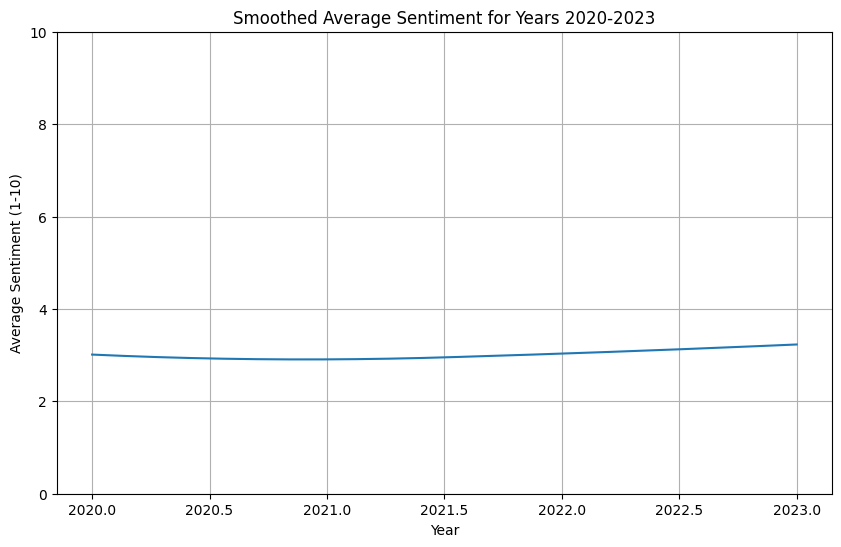

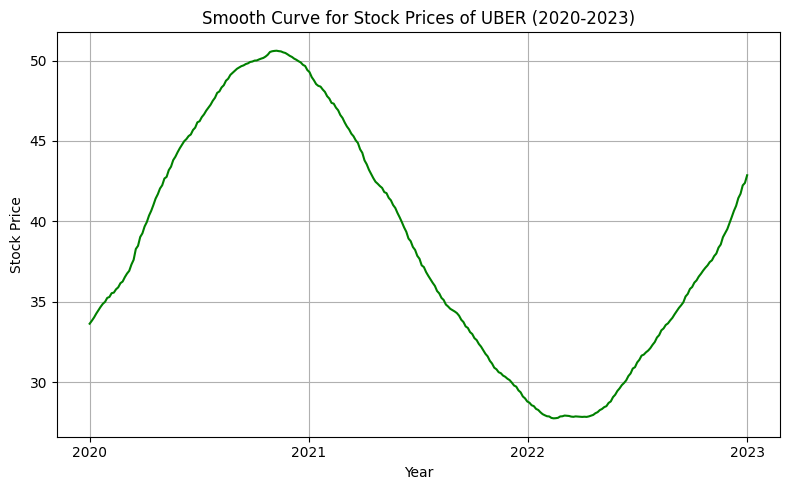

Similarity Percentage between the curves: 61.38%


In [17]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np
from textblob import TextBlob  # Add this import statement

# Download NLTK's vader lexicon
nltk.downloader.download('vader_lexicon')

# Import SentimentIntensityAnalyzer from NLTK
from nltk.sentiment import SentimentIntensityAnalyzer

# Load the CSV file containing reviews
data = pd.read_csv('sorted_dataset.csv')
# Assuming 'Datetime' is the column name containing datetime information
# Convert 'Datetime' column to datetime type if it's not already in that format
data['review_timestamp'] = pd.to_datetime(data['review_timestamp'])
# Initialize SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Function to perform sentiment analysis using NLTK and map scores to a 1-10 scale
def analyze_sentiment(text):
    blob = TextBlob(str(text))
    sentiment_score = blob.sentiment.polarity
    # Map sentiment score to a 1-5 scale
    mapped_score = (sentiment_score + 1) * 2.5
    return mapped_score

# Apply sentiment analysis to the 'ReviewHeader' column and create a new column for mapped scores
data['Sentiment_1_to_10'] = data['review_text'].apply(analyze_sentiment)

# Filter data for the period 2014-2023
filtered_data = data[(data['review_timestamp'].dt.year >= 2020) & (data['review_timestamp'].dt.year <= 2023)].copy()

# Extract the year from the datetime column using .dt accessor and .loc to avoid SettingWithCopyWarning
filtered_data.loc[:, 'Year'] = filtered_data['review_timestamp'].dt.year

# Grouping the filtered data by year and calculating the average sentiment
avg_sentiment_yearly = filtered_data.groupby('Year')['Sentiment_1_to_10'].mean()

# Smooth the curve using make_interp_spline from scipy
x_smooth = avg_sentiment_yearly.index
y_smooth = avg_sentiment_yearly.values
x_smooth_new = np.linspace(x_smooth.min(), x_smooth.max(), 300)
spl = make_interp_spline(x_smooth, y_smooth, k=2)  # Decreased k for smoother curve
y_smooth_new = spl(x_smooth_new)

# Create a line chart with smooth curve (without points/markers)
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-')  # Removed marker='o'

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Average Sentiment (1-10)')
plt.title('Smoothed Average Sentiment for Years 2020-2023')
plt.ylim(0, 10)
# Show grid
plt.grid(True)

# Show the plot
plt.show()

from IPython.display import display, HTML
display(HTML("<br><br><br>"))

# Load data from CSV file for stock prices (code two)
file_path = 'Uber_stock_prices_yahoo.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Filter data for the period starting from 2014
start_date = '2020-01-01'
end_date = '2023-12-31'

# Filter data for the specified period
filtered_data = df.loc[start_date:end_date, 'Open'].dropna()

# Smooth the curve for stock prices
rolling_avg = filtered_data.rolling(window=228).mean().dropna()

# Smooth the curve further
x_smooth_2 = rolling_avg.index
y_smooth_2 = rolling_avg.values
x_smooth_numeric = (x_smooth_2 - pd.Timestamp(start_date)) // pd.Timedelta('1s')
x_smooth_new_2 = np.linspace(x_smooth_numeric.min(), x_smooth_numeric.max(), 300)
spl_2_second = make_interp_spline(x_smooth_numeric, y_smooth_2, k=5)
y_smooth_new_2_second = spl_2_second(x_smooth_new_2)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_smooth_new_2, y_smooth_new_2_second, linestyle='-', color='green')
plt.xlabel('Year')
plt.ylabel('Stock Price')
plt.title('Smooth Curve for Stock Prices of UBER (2020-2023)')
plt.grid(True)

# Customize x-axis to display years
years = pd.date_range(start=start_date, end=end_date, freq='YS').year
plt.xticks(np.linspace(x_smooth_numeric.min(), x_smooth_numeric.max(), len(years)), years)

plt.tight_layout()
plt.show()

# Calculate similarity between the two curves
correlation = np.corrcoef(y_smooth_new, y_smooth_new_2_second)[0, 1]  # Change y_smooth_new_1 to y_smooth_new
similarity_percentage = abs(correlation) * 100
print(f"Similarity Percentage between the curves: {similarity_percentage:.2f}%")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


        date  avg_sentiment  review_count  avg_rating
0 2020-01-01       0.110069           323    3.260062
1 2020-01-02       0.124328           299    3.311037
2 2020-01-03       0.127153           303    3.267327
3 2020-01-04       0.043441           307    3.022801
4 2020-01-05       0.140696           305    3.475410
        date  avg_sentiment  review_count  avg_rating       Open      Close  \
0 2020-01-02       0.124328           299    3.311037  29.940001  30.990000   
1 2020-01-03       0.127153           303    3.267327  30.620001  31.370001   
2 2020-01-06       0.122842           338    3.313609  31.010000  31.580000   
3 2020-01-07       0.116441           268    3.175373  31.790001  32.810001   
4 2020-01-08       0.129721           276    3.246377  32.730000  33.930000   

   price_change  daily_return  
0      1.049999           NaN  
1      0.750000      0.012262  
2      0.570000      0.006694  
3      1.020000      0.038949  
4      1.200001      0.034136  
Merged da

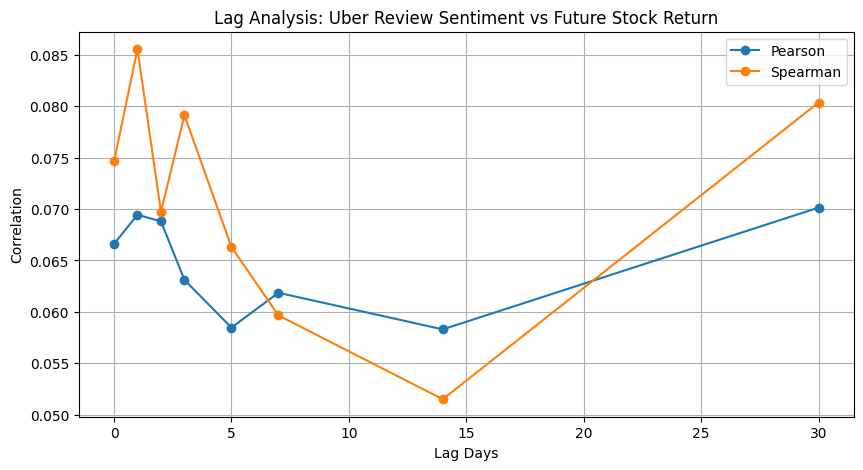

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

#  Load datasets
reviews = pd.read_csv("UBER_REVIEWS.csv", low_memory=False)
stock = pd.read_csv("Uber_stock_prices_yahoo.csv", low_memory=False)

#  Set your column names

review_text_col = "review_text"
review_date_col = "review_timestamp"
review_rating_col = "review_rating"

stock_date_col = "Date"
stock_open_col = "Open"
stock_close_col = "Close"


#  Sentiment analysis using VADER
import nltk
nltk.download("vader_lexicon")

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

reviews[review_text_col] = reviews[review_text_col].astype(str)

reviews["sentiment_score"] = reviews[review_text_col].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)


#  Prepare review dates
reviews[review_date_col] = pd.to_datetime(
    reviews[review_date_col], errors="coerce"
)

reviews = reviews.dropna(subset=[review_date_col])
reviews["date"] = reviews[review_date_col].dt.date

# Filter period
reviews = reviews[
    (reviews[review_date_col] >= "2020-01-01") &
    (reviews[review_date_col] <= "2023-12-31")
]


#  Aggregate daily sentiment
daily_sentiment = reviews.groupby("date").agg(
    avg_sentiment=("sentiment_score", "mean"),
    review_count=("sentiment_score", "count"),
    avg_rating=(review_rating_col, "mean")
).reset_index()

daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

print(daily_sentiment.head())


# Prepare stock data

stock[stock_date_col] = pd.to_datetime(stock[stock_date_col], errors="coerce")
stock = stock.dropna(subset=[stock_date_col])

stock = stock[
    (stock[stock_date_col] >= "2020-01-01") &
    (stock[stock_date_col] <= "2023-12-31")
]

stock = stock.sort_values(stock_date_col)

stock["price_change"] = stock[stock_close_col] - stock[stock_open_col]
stock["daily_return"] = stock[stock_close_col].pct_change()

stock = stock.rename(columns={stock_date_col: "date"})


#  Merge sentiment and stock data

merged = pd.merge(
    daily_sentiment,
    stock[["date", stock_open_col, stock_close_col, "price_change", "daily_return"]],
    on="date",
    how="inner"
)

merged = merged.sort_values("date").reset_index(drop=True)

print(merged.head())
print("Merged dataset shape:", merged.shape)


#  Lag analysis
# Sentiment today vs stock return after X days

lags = [0, 1, 2, 3, 5, 7, 14, 30]

lag_results = []

for lag in lags:
    target_col = f"future_return_after_{lag}_days"

    if lag == 0:
        merged[target_col] = merged["daily_return"]
    else:
        merged[target_col] = merged["daily_return"].shift(-lag)

    temp = merged[["avg_sentiment", "review_count", "avg_rating", target_col]].dropna()

    if len(temp) > 2:
        pearson_corr, pearson_p = pearsonr(temp["avg_sentiment"], temp[target_col])
        spearman_corr, spearman_p = spearmanr(temp["avg_sentiment"], temp[target_col])

        lag_results.append({
            "Lag_Days": lag,
            "Pearson_Correlation": pearson_corr,
            "Pearson_P_Value": pearson_p,
            "Spearman_Correlation": spearman_corr,
            "Spearman_P_Value": spearman_p
        })

lag_results_df = pd.DataFrame(lag_results)

print(lag_results_df)

# Save results
lag_results_df.to_csv("lag_analysis_results.csv", index=False)


#  Plot lag correlation result

plt.figure(figsize=(10, 5))
plt.plot(lag_results_df["Lag_Days"], lag_results_df["Pearson_Correlation"], marker="o", label="Pearson")
plt.plot(lag_results_df["Lag_Days"], lag_results_df["Spearman_Correlation"], marker="o", label="Spearman")
plt.xlabel("Lag Days")
plt.ylabel("Correlation")
plt.title("Lag Analysis: Uber Review Sentiment vs Future Stock Return")
plt.legend()
plt.grid(True)
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Linear Regression:
MAE: 0.7371215852350367
MSE: 0.6430371680343292

Support Vector Regression:
MAE: 0.4855371928269968
MSE: 0.24284009958706912

Gradient Boosting Regression:
MAE: 0.5942844581517426
MSE: 0.3938169023834485


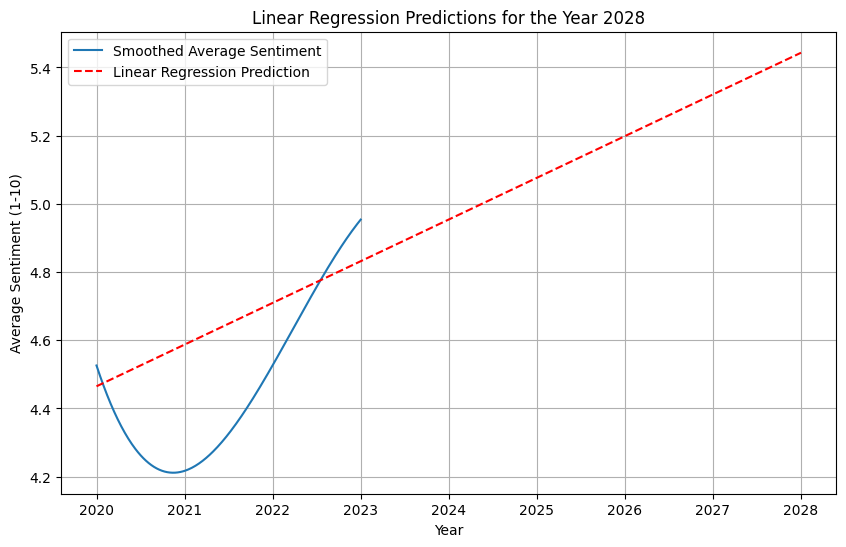

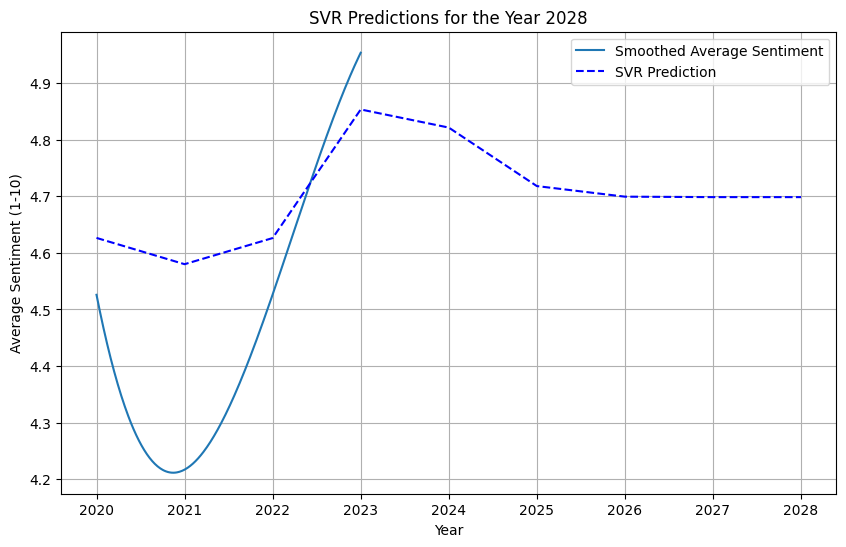

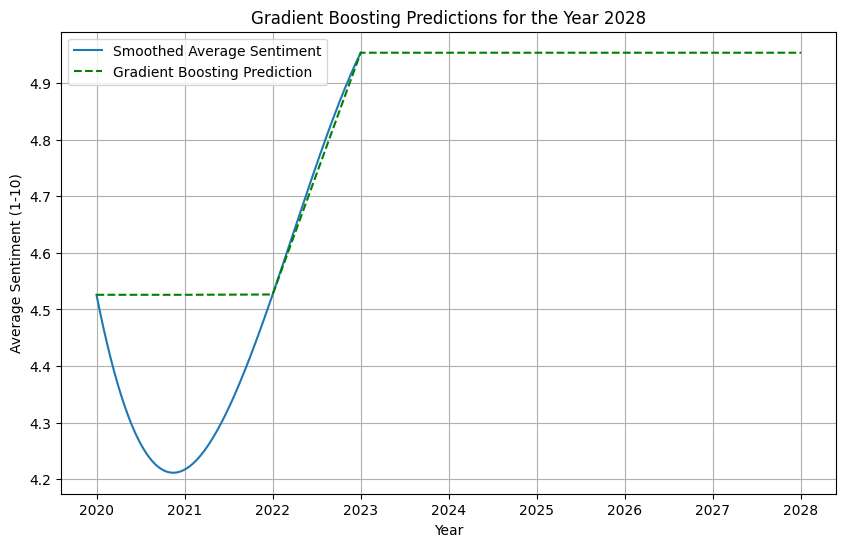

In [19]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Download NLTK's vader lexicon
nltk.download('vader_lexicon')

# Load the CSV file containing reviews
data = pd.read_csv('sorted_dataset.csv')

# Assuming 'review_timestamp' is the column name containing datetime information
# Convert 'review_timestamp' column to datetime type if it's not already in that format
data['review_timestamp'] = pd.to_datetime(data['review_timestamp'])

# Initialize SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Function to perform sentiment analysis using NLTK and map scores to a 1-10 scale
def analyze_sentiment(text):
    scores = sid.polarity_scores(str(text))
    mapped_score = (scores['compound'] + 1) * 4
    return mapped_score

# Apply sentiment analysis to the 'review_text' column and create a new column for mapped scores
data['Sentiment_1_to_10'] = data['review_text'].apply(analyze_sentiment)

# Filter data for the period 2020-2023
filtered_data = data[(data['review_timestamp'].dt.year >= 2020) & (data['review_timestamp'].dt.year <= 2023)].copy()

# Extract the year from the 'review_timestamp' column using .dt accessor and .loc to avoid SettingWithCopyWarning
filtered_data.loc[:, 'Year'] = filtered_data['review_timestamp'].dt.year

# Grouping the filtered data by year and calculating the average sentiment
avg_sentiment_yearly = filtered_data.groupby('Year')['Sentiment_1_to_10'].mean()

# Smooth the curve using make_interp_spline from scipy with lower k value for less curvature
x_smooth = avg_sentiment_yearly.index
y_smooth = avg_sentiment_yearly.values
x_smooth_new = np.linspace(x_smooth.min(), x_smooth.max(), 300)  # Increase number of points for smoother curve
spl = make_interp_spline(x_smooth, y_smooth, k=3)  # Decreased k value for less curvature
y_smooth_new = spl(x_smooth_new)


# Prepare data for regression models
X = avg_sentiment_yearly.index.values.reshape(-1, 1)
y = avg_sentiment_yearly.values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Train SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Train Gradient Boosting Regression model
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

# Generate future dates up to 2028
future_dates = np.arange(2020, 2029).reshape(-1, 1)

# Make predictions for future dates using each model
lr_predictions = lr_model.predict(future_dates)
svr_predictions = svr_model.predict(future_dates)
gb_predictions = gb_model.predict(future_dates)

# Reshape predictions to match the shape of y_test
y_test_reshaped = np.mean(y_test) * np.ones((future_dates.shape[0], 1))

# Evaluate models
def evaluate_model(predictions, y_true):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    return mae, mse

lr_mae, lr_mse = evaluate_model(lr_predictions, y_test_reshaped)
svr_mae, svr_mse = evaluate_model(svr_predictions, y_test_reshaped)
gb_mae, gb_mse = evaluate_model(gb_predictions, y_test_reshaped)

#Mean Absolute Error
#Mean Squared Error
print("Linear Regression:")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print()
print("Support Vector Regression:")
print("MAE:", svr_mae)
print("MSE:", svr_mse)
print()
print("Gradient Boosting Regression:")
print("MAE:", gb_mae)
print("MSE:", gb_mse)

# Plot the Linear Regression Predictions
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-', label='Smoothed Average Sentiment')
plt.plot(future_dates, lr_predictions, linestyle='--', color='red', label='Linear Regression Prediction')
plt.xlabel('Year')
plt.ylabel('Average Sentiment (1-10)')
plt.title('Linear Regression Predictions for the Year 2028')
plt.legend()
plt.grid(True)
plt.show()

from IPython.display import display, HTML
display(HTML("<br><br><br>"))

# Plot the SVR Predictions
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-', label='Smoothed Average Sentiment')
plt.plot(future_dates, svr_predictions, linestyle='--', color='blue', label='SVR Prediction')
plt.xlabel('Year')
plt.ylabel('Average Sentiment (1-10)')
plt.title('SVR Predictions for the Year 2028')
plt.legend()
plt.grid(True)
plt.show()

from IPython.display import display, HTML
display(HTML("<br><br><br>"))

# Plot the Gradient Boosting Predictions
plt.figure(figsize=(10, 6))
plt.plot(x_smooth_new, y_smooth_new, linestyle='-', label='Smoothed Average Sentiment')
plt.plot(future_dates, gb_predictions, linestyle='--', color='green', label='Gradient Boosting Prediction')
plt.xlabel('Year')
plt.ylabel('Average Sentiment (1-10)')
plt.title('Gradient Boosting Predictions for the Year 2028')
plt.legend()
plt.grid(True)
plt.show()

#SVR is best becuase of lower MAE and MSE


In [20]:
import yfinance as yf
import pandas as pd

# Define the ticker symbol for crude oil futures
crude_oil_symbol = 'CL=F'

# Fetch historical data from Yahoo Finance for the specified date range
crude_oil_data = yf.download(crude_oil_symbol, start='2020-01-01', end='2023-12-31')

# Find the highest and lowest closing prices
max_close = crude_oil_data['Close'].max()
min_close = crude_oil_data['Close'].min()

# Calculate the range of prices
price_range = max_close - min_close

# Define sentiment scoring criteria
def assign_sentiment(row):
    price_difference = row['Close'] - min_close
    score = 1 + (price_difference / price_range) * 9
    return round(score)

# Apply sentiment scoring
crude_oil_data['Sentiment_Score'] = crude_oil_data.apply(assign_sentiment, axis=1)

# Print the first few rows of the fetched data with the added columns
print(crude_oil_data.head())

# Save the data to a CSV file
crude_oil_data.to_csv('CrudeOil_prices_with_sentiment.csv')

print('Crude oil data with sentiment scores saved successfully as "CrudeOil_prices_with_sentiment.csv"')


/tmp/ipykernel_972/896272061.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crude_oil_data = yf.download(crude_oil_symbol, start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open   Volume  \
Ticker           CL=F       CL=F       CL=F       CL=F     CL=F   
Date                                                              
2020-01-02  61.180000  61.599998  60.639999  61.599998   486873   
2020-01-03  63.049999  64.089996  61.130001  61.180000   885861   
2020-01-06  63.270000  64.720001  62.639999  63.709999   724236   
2020-01-07  62.700001  63.150002  62.110001  62.910000   582649   
2020-01-08  59.610001  65.650002  59.150002  62.840000  1205710   

Price      Sentiment_Score  
Ticker                      
Date                        
2020-01-02             7.0  
2020-01-03             7.0  
2020-01-06             7.0  
2020-01-07             7.0  
2020-01-08             6.0  
Crude oil data with sentiment scores saved successfully as "CrudeOil_prices_with_sentiment.csv"


/tmp/ipykernel_972/2122254379.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crude_oil_data = yf.download(crude_oil_symbol, start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


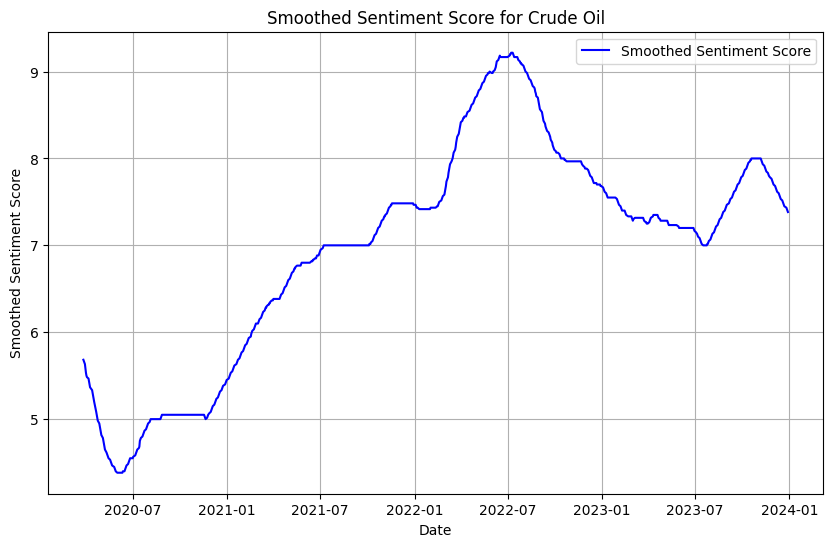

In [21]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Define the ticker symbol for crude oil futures
crude_oil_symbol = 'CL=F'

# Fetch historical data from Yahoo Finance for the specified date range
crude_oil_data = yf.download(crude_oil_symbol, start='2020-01-01', end='2023-12-31')

# Find the highest and lowest closing prices
max_close = crude_oil_data['Close'].max()
min_close = crude_oil_data['Close'].min()

# Calculate the range of prices
price_range = max_close - min_close

# Define sentiment scoring criteria
def assign_sentiment(row):
    price_difference = row['Close'] - min_close
    score = 1 + (price_difference / price_range) * 9
    return round(score)

# Apply sentiment scoring
crude_oil_data['Sentiment_Score'] = crude_oil_data.apply(assign_sentiment, axis=1)

# Smooth the sentiment scores using a simple moving average
crude_oil_data['Smoothed_Score'] = crude_oil_data['Sentiment_Score'].rolling(window=60).mean()

# Plot the smoothed sentiment scores
plt.figure(figsize=(10, 6))
plt.plot(crude_oil_data.index, crude_oil_data['Smoothed_Score'], color='blue', label='Smoothed Sentiment Score')
plt.title('Smoothed Sentiment Score for Crude Oil')
plt.xlabel('Date')
plt.ylabel('Smoothed Sentiment Score')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the CSV file containing reviews
data = pd.read_csv('CrudeOil_prices_with_sentiment.csv')

num_rows = data.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1008


/tmp/ipykernel_972/4210984495.py:42: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(
/tmp/ipykernel_972/4210984495.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(


Linear Regression:
MAE: 2.488133478730474
MSE: 9.217967739143653

Support Vector Regression:
MAE: 0.2898801109437199
MSE: 0.21622021890095067

Gradient Boosting Regression:
MAE: 0.8608500959005793
MSE: 1.060642640682916


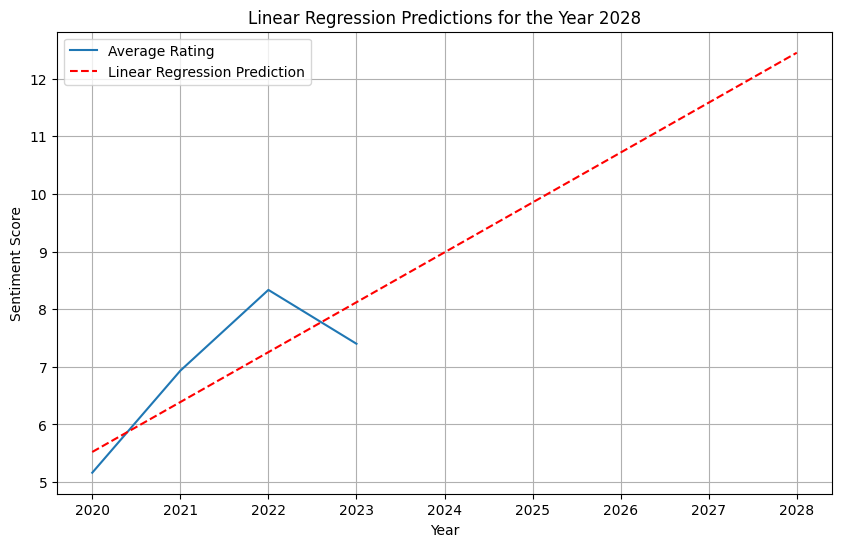

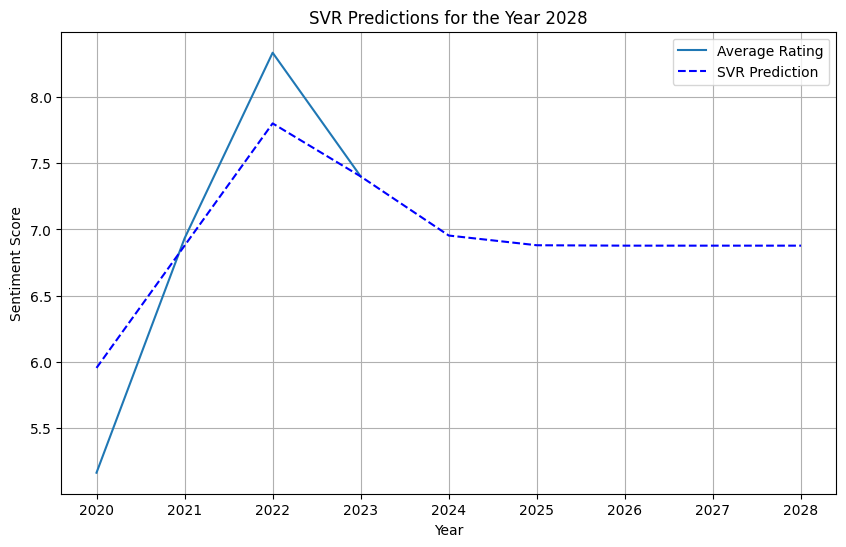

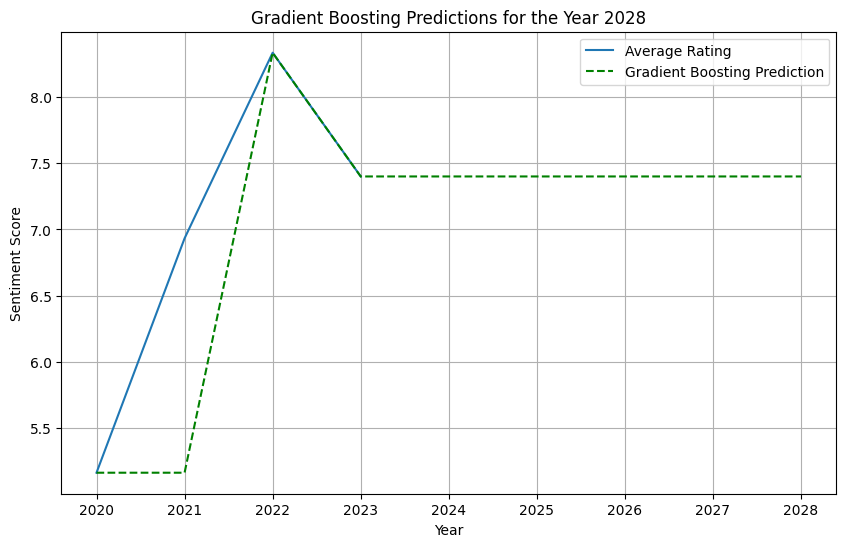

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Clean column names
data.columns = data.columns.astype(str).str.strip()

# Find the date column automatically
if 'Date' not in data.columns:

    possible_date_columns = [
        'date',
        'DATE',
        'review_timestamp',
        'Review_Timestamp',
        'timestamp'
    ]

    date_column = None

    for col in possible_date_columns:
        if col in data.columns:
            date_column = col
            break


    # find the column containing values such as 2020-01-23
    if date_column is None:

        for col in data.columns:

            try:
                converted = pd.to_datetime(
                    data[col],
                    errors='coerce'
                )

                if converted.notna().mean() > 0.8:
                    date_column = col
                    break

            except:
                pass

    if date_column is None:
        raise ValueError(
            "Could not find the date column. Columns are: "
            + str(data.columns.tolist())
        )

    data.rename(
        columns={date_column: 'Date'},
        inplace=True
    )


# Convert Date column to datetime
data['Date'] = pd.to_datetime(
    data['Date'],
    errors='coerce'
)

# Remove rows where Date could not be converted
data = data.dropna(
    subset=['Date']
)


# Filter data for the period 2020-2023
filtered_data = data[
    (data['Date'].dt.year >= 2020) &
    (data['Date'].dt.year <= 2023)
].copy()


# Extract year from Date
filtered_data.loc[:, 'Year'] = (
    filtered_data['Date'].dt.year
)


# Group data by year and calculate average sentiment score
avg_rating_yearly = (
    filtered_data
    .groupby('Year')['Sentiment_Score']
    .mean()
)


# Prepare data for regression models
X = avg_rating_yearly.index.values.reshape(-1, 1)

y = avg_rating_yearly.values


# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Train Linear Regression model
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)


# Train SVR model
svr_model = SVR(
    kernel='rbf'
)

svr_model.fit(
    X_train,
    y_train
)


# Train Gradient Boosting Regression model
gb_model = GradientBoostingRegressor()

gb_model.fit(
    X_train,
    y_train
)


# Generate future dates up to 2026
future_dates = np.arange(
    2020,
    2029
).reshape(-1, 1)


# Make predictions
lr_predictions = lr_model.predict(
    future_dates
)

svr_predictions = svr_model.predict(
    future_dates
)

gb_predictions = gb_model.predict(
    future_dates
)


# Reshape predictions to match y_test
y_test_reshaped = (
    np.mean(y_test) *
    np.ones(
        (future_dates.shape[0], 1)
    )
)


# Evaluate models
def evaluate_model(predictions, y_true):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    mse = mean_squared_error(
        y_true,
        predictions
    )

    return mae, mse


lr_mae, lr_mse = evaluate_model(
    lr_predictions,
    y_test_reshaped
)

svr_mae, svr_mse = evaluate_model(
    svr_predictions,
    y_test_reshaped
)

gb_mae, gb_mse = evaluate_model(
    gb_predictions,
    y_test_reshaped
)


print("Linear Regression:")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print()

print("Support Vector Regression:")
print("MAE:", svr_mae)
print("MSE:", svr_mse)
print()

print("Gradient Boosting Regression:")
print("MAE:", gb_mae)
print("MSE:", gb_mse)


# Linear Regression plot
plt.figure(figsize=(10, 6))

plt.plot(
    X,
    y,
    linestyle='-',
    label='Average Rating'
)

plt.plot(
    future_dates,
    lr_predictions,
    linestyle='--',
    color='red',
    label='Linear Regression Prediction'
)

plt.xlabel('Year')

plt.ylabel('Sentiment Score')

plt.title(
    'Linear Regression Predictions for the Year 2028'
)

plt.legend()

plt.grid(True)

plt.show()

from IPython.display import display, HTML
display(HTML("<br><br><br>"))

# SVR plot
plt.figure(figsize=(10, 6))

plt.plot(
    X,
    y,
    linestyle='-',
    label='Average Rating'
)

plt.plot(
    future_dates,
    svr_predictions,
    linestyle='--',
    color='blue',
    label='SVR Prediction'
)

plt.xlabel('Year')

plt.ylabel('Sentiment Score')

plt.title(
    'SVR Predictions for the Year 2028'
)

plt.legend()

plt.grid(True)

plt.show()

from IPython.display import display, HTML
display(HTML("<br><br><br>"))

# Gradient Boosting plot
plt.figure(figsize=(10, 6))

plt.plot(
    X,
    y,
    linestyle='-',
    label='Average Rating'
)

plt.plot(
    future_dates,
    gb_predictions,
    linestyle='--',
    color='green',
    label='Gradient Boosting Prediction'
)

plt.xlabel('Year')

plt.ylabel('Sentiment Score')

plt.title(
    'Gradient Boosting Predictions for the Year 2028'
)

plt.legend()

plt.grid(True)

plt.show()